# CaCO3 precipitation with CO2(g)
- solves saturated concentration of Ca2+ under fixed pCO2
- considers activity coefficients (Davies model)

In [1]:
import sys
sys.path.append('../')

In [2]:
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# Load data

In [3]:
import eq_solver

In [4]:
path = 'Ca-CO3.yaml'
s = eq_solver.System.from_yaml(path)
pprint(s)

System(activity_model='davies',
       species=(Species(name='H+'),
                Species(name='OH-'),
                Species(name='CO2(g)'),
                Species(name='CO2aq'),
                Species(name='HCO3-'),
                Species(name='CO3^2-'),
                Species(name='Ca2+'),
                Species(name='[CaCO3]aq'),
                Species(name='[CaHCO3]aq'),
                Species(name='CaCO3(s)'),
                Species(name='[CaOH]+aq'),
                Species(name='Ca(OH)2(s)')),
       components=(Component(name='proton',
                             base_species=Species(name='H+'),
                             constraint=<Constraint.CHARGE: 1>,
                             charge=1),
                   Component(name='carbonate',
                             base_species=Species(name='CO2(g)'),
                             constraint=<Constraint.DIRECT: 2>,
                             charge=0),
                   Component(name='calcium',
          

In [5]:
print('---------- Equilibrium table generated from yaml ----------')
display(pd.concat([
    s.stoichiometry_matrix_as_df(), s.logK_as_df()
], axis='columns'))

---------- Equilibrium table generated from yaml ----------


,H+,CO2(g),Ca2+,logK
H+,1.0,-0.0,-0.0,0.00
OH-,-1.0,0.0,0.0,-14.00
CO2(g),0.0,1.0,-0.0,-0.00
CO2aq,-0.0,1.0,-0.0,-1.47
HCO3-,-1.0,1.0,-0.0,-7.77
CO3^2-,-2.0,1.0,-0.0,-18.10
Ca2+,0.0,-0.0,1.0,0.00
[CaCO3]aq,-2.0,1.0,1.0,-14.90
[CaHCO3]aq,-1.0,1.0,1.0,-6.50
CaCO3(s),-2.0,1.0,1.0,-9.62


# Problem 1: saturated concentration of Ca(OH)2

In [6]:
cond = eq_solver.Conditions.from_dict(
    system=s,
    conditions={'carbonate': 0.0, 'calcium': 0.1}
)
f = eq_solver.FitFunc(system=s, cond=cond)
r = f.solve()
print(f'- total Ca2+ = {r.total_conc_in_liquid("calcium"):.3f} mol/L')
print(f'-         pH = {r.pH():.2f}')

- total Ca2+ = 0.021 mol/L
-         pH = 12.48


In [7]:
# Details
print('- concentration of each species: ')
display(pd.Series(r.spc_c, index=s.species))
print('- solver results: ')
display(r.sol)

- concentration of each species: 


Species(name='H+')            4.050646e-13
Species(name='OH-')           3.680742e-02
Species(name='CO2(g)')        0.000000e+00
Species(name='CO2aq')         0.000000e+00
Species(name='HCO3-')         0.000000e+00
Species(name='CO3^2-')        0.000000e+00
Species(name='Ca2+')          1.579459e-02
Species(name='[CaCO3]aq')     0.000000e+00
Species(name='[CaHCO3]aq')    0.000000e+00
Species(name='CaCO3(s)')      6.367414e-07
Species(name='[CaOH]+aq')     5.218243e-03
Species(name='Ca(OH)2(s)')    7.898653e-02
dtype: float64

- solver results: 


     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 0.000e+00 -6.367e-07  0.000e+00  0.000e+00  0.000e+00]
           x: [-1.248e+01 -2.148e+00  6.367e-07  7.899e-02  5.260e-02]
        cost: 2.027194732974784e-13
         jac: [[ 5.218e-02 -2.101e-01 ... -4.343e+00 -3.968e-01]
               [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
               ...
               [ 8.582e-01  1.000e+00 ...  0.000e+00  1.494e+00]
               [-3.995e-01  6.501e-01 ...  0.000e+00 -6.631e+00]]
        grad: [ 0.000e+00  0.000e+00  6.367e-07  0.000e+00  0.000e+00]
  optimality: 4.0543925704675473e-13
 active_mask: [0 0 0 0 0]
        nfev: 22
        njev: 22

# Problem 1.5: What if we don't consider activity coefficients?

In [8]:
from dataclasses import replace
s2 = replace(s, activity_model='none')
cond = eq_solver.Conditions.from_dict(
    system=s2,
    conditions={'carbonate': 0.0, 'calcium': 0.1}
)
f = eq_solver.FitFunc(system=s2, cond=cond)
r = f.solve()

print(f'- total Ca2+ = {r.total_conc_in_liquid("calcium"):.3f} mol/L')
print(f'-         pH = {r.pH():.2f}')

- total Ca2+ = 0.015 mol/L
-         pH = 12.40


# Problem 2: Ca2+ solution, under given pCO2

In [9]:
pco2 = np.logspace(-6, 1, 100)
ca = 0.02  # total mole of Ca2+
cond_list = [eq_solver.Conditions.from_dict(s, {'carbonate': p, 'calcium': ca}) for p in pco2]

In [10]:
l = eq_solver.solve_for_conditions(s, cond_list)
df = eq_solver.get_total_aq(l)
df  # negative total proton(aq) means H+ consumption through reactions.

,cond.direct.carbonate,cond.total.calcium,sol.rmse,sol.retries,sol.nfev,pH,proton,carbonate,calcium
0,0.000001,0.02,9.178117e-09,0,26,9.792259,-0.000249,0.000147,0.000124
1,0.000001,0.02,1.852567e-12,0,16,9.754630,-0.000251,0.000155,0.000126
2,0.000001,0.02,6.646042e-12,0,7,9.716416,-0.000255,0.000163,0.000127
3,0.000002,0.02,6.538399e-12,0,7,9.677630,-0.000259,0.000173,0.000129
4,0.000002,0.02,3.234444e-12,0,8,9.638289,-0.000263,0.000182,0.000132
...,...,...,...,...,...,...,...,...,...
95,5.214008,0.02,2.046982e-09,0,19,5.515994,-0.040000,0.216671,0.020000
96,6.135907,0.02,1.404333e-16,0,8,5.445312,-0.040000,0.247911,0.020000
97,7.220809,0.02,3.065260e-11,0,5,5.374628,-0.040000,0.284674,0.020000
98,8.497534,0.02,3.065745e-11,0,5,5.303943,-0.040000,0.327936,0.020000


In [11]:
# save data as csv
df_all = eq_solver.get_all(l)
display(df_all)
df_all.to_csv('CaCO3-under-pCO2.csv', encoding='utf-8')

,cond.direct.carbonate,cond.total.calcium,sol.rmse,sol.retries,sol.nfev,pH,ionic strength,c_total.proton,c_total.carbonate,c_total.calcium,...,a.CO2(g),a.CO2aq,a.HCO3-,a.CO3^2-,a.Ca2+,a.[CaCO3]aq,a.[CaHCO3]aq,a.CaCO3(s),a.[CaOH]+aq,a.Ca(OH)2(s)
0,0.000001,0.02,9.178117e-09,0,26,9.792259,0.000390,-0.000249,0.000147,0.000124,...,0.0,3.388442e-08,0.000108,3.339000e-05,0.000119,0.000005,2.175285e-07,1.987564e-02,1.372512e-07,2.052289e-08
1,0.000001,0.02,1.852567e-12,0,16,9.754630,0.000394,-0.000251,0.000155,0.000126,...,0.0,3.987559e-08,0.000116,3.305526e-05,0.000120,0.000005,2.372401e-07,1.987435e-02,1.271982e-07,4.142188e-12
2,0.000001,0.02,6.646042e-12,0,7,9.716416,0.000398,-0.000255,0.000163,0.000127,...,0.0,4.692607e-08,0.000125,3.263925e-05,0.000122,0.000005,2.590941e-07,1.987269e-02,1.180439e-07,1.486144e-11
3,0.000002,0.02,6.538399e-12,0,7,9.677630,0.000404,-0.000259,0.000173,0.000129,...,0.0,5.522315e-08,0.000135,3.214722e-05,0.000124,0.000005,2.833417e-07,1.987066e-02,1.096956e-07,1.462054e-11
4,0.000002,0.02,3.234444e-12,0,8,9.638289,0.000410,-0.000263,0.000182,0.000132,...,0.0,6.498727e-08,0.000145,3.158520e-05,0.000126,0.000005,3.102636e-07,1.986825e-02,1.020710e-07,7.232731e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5.214008,0.02,2.046982e-09,0,19,5.515994,0.050776,-0.040000,0.216671,0.020000,...,0.0,1.766736e-01,0.035385,9.812465e-07,0.015388,0.000005,4.606744e-03,4.576592e-09,5.574711e-10,7.408808e-11
96,6.135907,0.02,1.404333e-16,0,8,5.445312,0.050778,-0.040000,0.247911,0.020000,...,0.0,2.079116e-01,0.035387,8.339214e-07,0.015389,0.000004,4.607086e-03,4.806203e-18,4.737482e-10,5.631447e-16
97,7.220809,0.02,3.065260e-11,0,5,5.374628,0.050780,-0.040000,0.284674,0.020000,...,0.0,2.446729e-01,0.035389,7.087106e-07,0.015389,0.000004,4.607392e-03,4.846591e-11,4.025959e-10,4.846574e-11
98,8.497534,0.02,3.065745e-11,0,5,5.303943,0.050782,-0.040000,0.327936,0.020000,...,0.0,2.879340e-01,0.035391,6.022975e-07,0.015389,0.000003,4.607671e-03,4.847415e-11,3.421280e-10,4.847403e-11


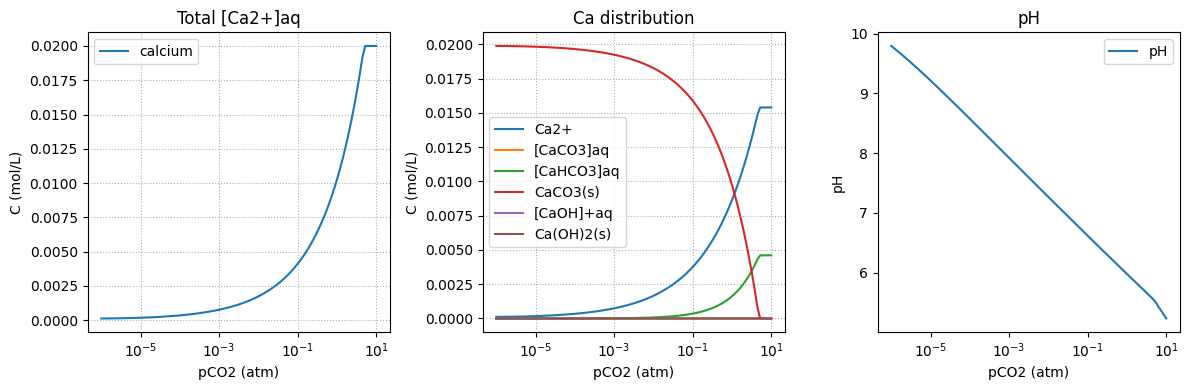

In [13]:
# Total solubility of Ca2+, Ca2+ distribution, pH
fig, axes = plt.subplots(ncols=3)
fig.set_size_inches(12, 4)
plt.sca(axes[0])
df.plot(x='cond.direct.carbonate', y='calcium', title='Total [Ca2+]aq', ax=axes[0])
plt.xscale('log')
plt.ylabel('C (mol/L)')
plt.xlabel('pCO2 (atm)')
plt.grid(True, ls=':')

plt.sca(axes[1])
df_Ca = eq_solver.get_distribution(l, 'calcium')
df_Ca.plot(x='cond.direct.carbonate', title='Ca distribution',
           y=[c for c in df_Ca.columns if 'Ca' in c], 
           ax=axes[1])
plt.xscale('log')
plt.ylabel('C (mol/L)')
plt.xlabel('pCO2 (atm)')
plt.grid(True, ls=':')

plt.sca(axes[2])
df.plot(x='cond.direct.carbonate', y='pH', title='pH', ax=axes[2])
plt.xscale('log')
plt.ylabel('pH')
plt.xlabel('pCO2 (atm)')
fig.set_tight_layout(True)

# Problem 3: temperature dependence of solubility of Ca(OH)2

In [15]:
t_list = np.linspace(0, 100, 21)
systems = [s.with_temperature(t + 273.15) for t in t_list]
conds = [eq_solver.Conditions.from_dict(s, {'calcium': 0.1, 'carbonate': 0.0}) for s in systems]
solubility = []

for s, c in zip(systems, conds):
    f = eq_solver.FitFunc(system=s, cond=c)
    r = f.solve()
    cCa = r.total_conc_in_liquid('calcium')
    solubility.append(cCa * 74.093 / 10) # in g/100mL

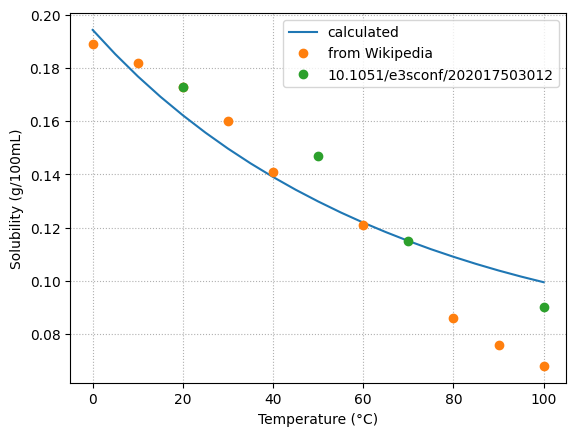

In [16]:
plt.figure()
plt.plot(t_list, solubility, label='calculated')
plt.plot([0, 10, 20, 30, 40, 60, 80, 90, 100],
         [0.189, 0.182, 0.173, 0.16, 0.141, 0.121, 0.086, 0.076, 0.068],
         'o',
         label='from Wikipedia')
plt.plot([20, 50, 70, 100],
         [0.173, 0.147, 0.115, 0.09],
         'o',
         label='10.1051/e3sconf/202017503012')
plt.xlabel('Temperature (°C)')
plt.ylabel('Solubility (g/100mL)')
plt.grid(True, ls=':')
plt.legend()